# PRÁCTICA 4

**Se recomienda ejecutar los códigos de este jupyer notebook en la misma carpeta donde reside dicho documento, debido a la dependencia de ciertos documentos para el correcto uso del mismo.**

En primer lugar, vamos a importar las librerías necesarias y vamos a importar los csv necesarios.

In [11]:
import pandas as pd
from scipy.stats import zscore
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('fuga_clientes_empresa_telefonica_construccion.csv')
df

,Customer ID,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,Total Call centre complaint calls,Network type subscription in Month 1,Network type subscription in Month 2,Most Loved Competitor network in Month 1,Most Loved Competitor network in Month 2,Churn Status
0,ADF0039,1345,44.83,963.0800,0.00,0.00,1.473830e+01,788,2940,1458,4,2G,2G,Weematel,Uxaa,0
1,ADF0040,2713,90.43,5979.4120,48.38,505.00,8.344973e+07,1127,0,58255,2,3G,3G,Uxaa,Uxaa,0
2,ADF0041,746,24.87,114.9000,14.94,13.75,7.115992e+04,15,131,2978,1,3G,3G,PQza,PQza,1
3,ADF0043,1967,65.57,54.1000,8.75,0.00,1.839360e+01,70,696,2274,1,3G,2G,PQza,PQza,1
4,ADF0044,2576,85.87,1222.2204,41.85,131.25,3.537593e+05,98,18635,34804,3,2G,2G,ToCall,Uxaa,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,ADF1996,3836,127.87,24438.8300,664.92,8295.00,1.737079e+06,678,72120,337192,10,3G,3G,ToCall,Weematel,1
1107,ADF1997,105,3.50,75.4000,10.50,10.00,2.401224e+06,22,2532,1522,2,2G,3G,Uxaa,PQza,1
1108,ADF1998,2172,72.40,16.6420,0.00,8.75,1.312746e+05,5,0,203,2,2G,2G,PQza,PQza,1
1109,ADF1999,2774,92.47,652.6300,4.14,57.50,2.166006e+06,526,741,716,1,3G,3G,Weematel,Uxaa,0


Una vez hemos importado las librerías necesarias y hemos definido el dataframe vamos a exportar el preprocesado que realizamos en la práctica 3 incluyendo la estandarización.

In [ ]:
# Quitamos el target y la id del dataframe para evitar problemas
id_df = df["Customer ID"].copy()
df_mod = df.drop(columns=["Churn Status"])
df_mod = df.drop(columns=["Customer ID"])

# Separamos los dataframes para tratarlos de forma diferente en variables numéricas y en variables categóricas
df_num = df_mod.select_dtypes(include="number")
df_cat = df_mod.select_dtypes(exclude="number")

# Al dataframe categórico le aplico get_dummies para tratarlo debidamente
df_cat = pd.get_dummies(df_cat,drop_first=True)

# Volvemos a unir los dos dataframes
df_mod = pd.concat([df_num,df_cat],axis=1)

# Estandarizamos todo el dataframe
df_mod = (df_mod - df_mod.mean()) / df_mod.std()

# Y por último eliminamos outliers utilizando zscore o el método de las 3 sigmas
zscore_df = df_mod.apply(zscore)
df_mod = df_mod[(zscore_df.abs() < 3).all(axis=1)]


In [14]:
df_mod

,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,Total Call centre complaint calls,...,Most Loved Competitor network in Month 1_PQza,Most Loved Competitor network in Month 1_ToCall,Most Loved Competitor network in Month 1_Uxaa,Most Loved Competitor network in Month 1_Weematel,Most Loved Competitor network in Month 1_Zintel,Most Loved Competitor network in Month 2_PQza,Most Loved Competitor network in Month 2_ToCall,Most Loved Competitor network in Month 2_Uxaa,Most Loved Competitor network in Month 2_Weematel,Most Loved Competitor network in Month 2_Zintel
2,-0.602949,-0.602874,-0.546438,-0.268223,-0.165233,-0.309326,-0.625830,-0.495557,-0.356865,-0.394801,...,1.751238,-0.412980,-0.533045,-0.326309,-0.349446,1.812902,-0.223717,-1.148141,-0.198125,-0.172135
3,0.357202,0.357280,-0.592593,-0.373844,-0.207727,-0.319018,-0.442608,-0.448338,-0.375781,-0.394801,...,1.751238,-0.412980,-0.533045,-0.326309,-0.349446,1.812902,-0.223717,-1.148141,-0.198125,-0.172135
4,0.836098,0.836177,0.294161,0.190945,0.197900,-0.270829,-0.349331,1.050875,0.498286,0.406339,...,-0.570511,2.419246,-0.533045,-0.326309,-0.349446,-0.551105,-0.223717,0.870189,-0.198125,-0.172135
5,-0.974113,-0.974196,0.289082,0.756588,0.024060,0.358043,-0.435945,-0.044180,-0.285418,0.005769,...,1.751238,-0.412980,-0.533045,-0.326309,-0.349446,-0.551105,-0.223717,-1.148141,-0.198125,-0.172135
6,-1.062186,-1.062191,0.198230,-0.523146,0.089733,2.506930,-0.369319,-0.456361,0.088982,-0.394801,...,1.751238,-0.412980,-0.533045,-0.326309,-0.349446,-0.551105,-0.223717,0.870189,-0.198125,-0.172135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1103,0.768470,0.768471,-0.587590,-0.199800,-0.130465,-0.318877,-0.672468,-0.506505,-0.432072,0.005769,...,1.751238,-0.412980,-0.533045,-0.326309,-0.349446,1.812902,-0.223717,-1.148141,-0.198125,-0.172135
1104,-0.627326,-0.627409,-0.178048,-0.472128,-0.207727,-0.179166,0.060419,-0.506505,-0.332548,0.406339,...,-0.570511,-0.412980,-0.533045,-0.326309,-0.349446,-0.551105,-0.223717,0.870189,-0.198125,-0.172135
1105,0.809361,0.809283,0.209993,0.387513,-0.203864,-0.179524,0.876589,0.260610,-0.224908,-0.394801,...,1.751238,-0.412980,-0.533045,-0.326309,-0.349446,-0.551105,-0.223717,0.870189,-0.198125,-0.172135
1107,-1.107008,-1.107014,-0.576423,-0.343984,-0.176822,0.008089,-0.602511,-0.294898,-0.395987,0.005769,...,-0.570511,-0.412980,1.874325,-0.326309,-0.349446,1.812902,-0.223717,-1.148141,-0.198125,-0.172135


Ahora que hemos hecho el preprocesamiento debidamente con la inclusión de la estandarización vamos a aplicar PCA. Es importante recalcar que en X no deberá estar contenida la variable a predecir, por eso hemos quitado el target y hemos dejado el resto del dataframe. 

In [15]:
X = df_mod
pca = PCA() # núm. componentes principales = núm. variables 
X_pca = pca.fit_transform(X)
print(X_pca.shape)

(811, 26)


Una vez hemos hecho PCA vamos a hacer ciertas comprobaciones tanto analíticas como visuales para comprobar la eficiencia del PCA. Por otra parte, vamos a centrarnos en la varianza para probar la potencia de nuestro dataframe.

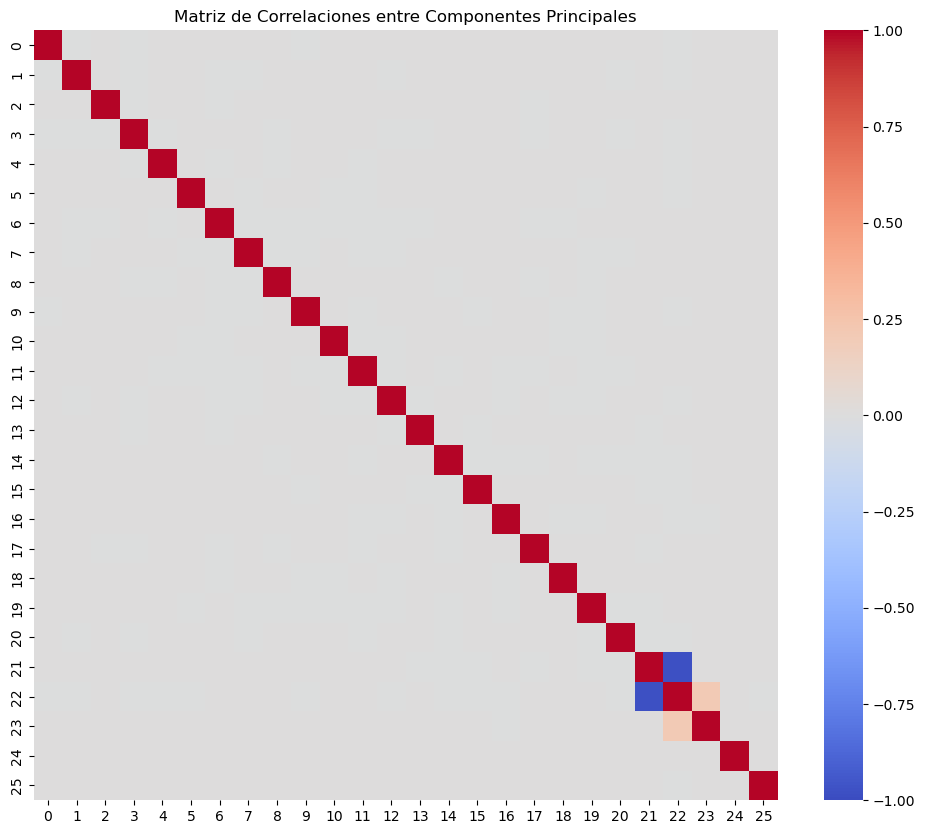

In [16]:
# Calculamos la matriz de correlaciones entre componentes principales para ver si es 0
correlaciones = np.corrcoef(X_pca.T)

# Creamos un mapa de calor para verlo de forma visual
plt.figure(figsize=(12, 10))
sns.heatmap(correlaciones,
            cmap='coolwarm',    # Le ponemos una gama de colores
            vmin=-1, vmax=1,      # Rango de -1 a 1
            )
plt.title('Matriz de Correlaciones entre Componentes Principales')
plt.show()


Vemos que la relación entre las distintas variables es nula. Únicamente es 1 cuando se relaciona consigo mismo. Ahora vamos a centrarnos en la varianza.

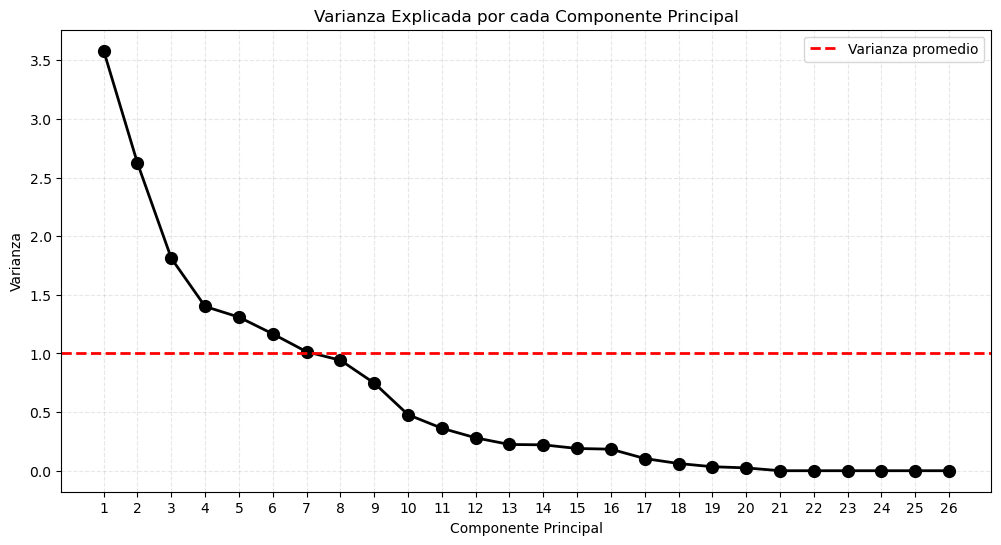

In [17]:
# Obtenemos la varianza por cada componente. Tenemos 25
varianza_explicada = pca.explained_variance_

# Creamos la gráfica 
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(varianza_explicada) + 1), 
        varianza_explicada,
        marker='o',           
        linewidth=2,          
        markersize=8,         
        color='black',    
        markerfacecolor='black',  
        markeredgecolor='black',  
        markeredgewidth=1.5)

plt.xlabel('Componente Principal')
plt.ylabel('Varianza')
plt.title('Varianza Explicada por cada Componente Principal')
plt.xticks(range(1, len(varianza_explicada) + 1))
plt.grid(True, alpha=0.3, linestyle='--')
# Línea de referencia en y=1
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Varianza promedio')
plt.legend()
plt.show()